In [7]:
import os
import requests
import json
from pathlib import Path

In [8]:
ACCESS_KEY = "5mTDa3t-OXGjj1xre9pasmd9FxEP_ZfNFnRmhuMkKe0"

IMAGES_DIR = Path("images")
DATA_DIR = Path("data")

IMAGES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

NB_IMAGES_PER_CATEGORY = 10

## Partie 1 : Récupération des images

A cause de la limite api de unspash nous récupérons uniquement 30 images

In [9]:
HEADERS = {"Authorization": f"Client-ID {ACCESS_KEY}"}


CATEGORIES = {
    "animaux": "animals",
    "batiments": "architecture",
    "paysage": "landscape",
}

metadata_list = []

for category_name, query in CATEGORIES.items():
    print(f"Chargement de la catégorie {category_name}...")

    url = "https://api.unsplash.com/search/photos"
    params = {
        "query": query,
        "per_page": NB_IMAGES_PER_CATEGORY,
        "page": 3,
        "orientation": "landscape",
    }

    response = requests.get(url, headers=HEADERS, params=params, timeout=30)
    response.raise_for_status()
    results = response.json()["results"]

    for i, photo in enumerate(results[:33], start=1):
        photo_id = photo["id"]

        url_photo = f"https://api.unsplash.com/photos/{photo_id}"
        response_photo = requests.get(url_photo, headers=HEADERS, timeout=30)
        response_photo.raise_for_status()
        photo_full = response_photo.json()

        # Nom du fichier
        filename = f"{category_name}_{photo_id}.jpg"
        filepath = IMAGES_DIR / filename

        # URL de l’image (regular ou full)
        image_url = photo_full["urls"]["regular"]

        # Téléchargement de l’image
        image_response = requests.get(image_url, stream=True, timeout=30)
        image_response.raise_for_status()

        with open(filepath, "wb") as f:
            for chunk in image_response.iter_content(chunk_size=8192):
                f.write(chunk)

        # Taille du fichier en Ko
        file_stat = filepath.stat()
        file_size_kb = round(file_stat.st_size / 1024, 2)

        # Metadonnées EXIF
        exif = photo_full.get("exif", {}) or {}
        make = exif.get("make") or ""
        model = exif.get("model") or ""
        camera = (make + " " + model).strip()
        aperture = exif.get("aperture")
        focal_length = exif.get("focal_length")
        iso = exif.get("iso")
        exposure = exif.get("exposure_time")

        # tags is array of dicts with "title" key, we extract titles
        tags = [tag["title"] for tag in photo_full.get("tags", []) if "title" in tag]

        taken_at = exif.get("created_at", "") or photo_full.get("created_at", "")

        licenses = photo_full.get("current_user_collections", [])
        license_str = "Unsplash license (check terms)"

        meta = {
            "nom_fichier": filename,
            "categorie": category_name,
            "largeur": photo_full["width"],
            "hauteur": photo_full["height"],
            "format_fichier": "jpg",
            "taille_fichier_kb": file_size_kb,
            "url_source": photo_full["urls"]["full"],
            "licence": license_str,
            "description": photo_full.get("description") or photo_full.get("alt_description"),
            "photographe": photo_full["user"]["name"],
            "page_unsplash": photo_full["links"]["html"],
            "date_creation_photo": photo_full["created_at"],
            "nombre_likes": photo_full.get("likes", 0),
            "tags": tags,
            "exif": {
                "camera_model": camera if camera else None,
                "taken_at": taken_at if taken_at else None,
                "aperture": aperture,
                "focal_length": focal_length,
                "iso": iso,
                "exposure_time": exposure,
            },
        }

        metadata_list.append(meta)

# Sauvegarde des métadonnées
output_path = DATA_DIR / "images_metadata.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(metadata_list, f, ensure_ascii=False, indent=2)

print(f"✅ {len(metadata_list)} images et métadonnées sauvegardées.")

Chargement de la catégorie animaux...
Chargement de la catégorie batiments...
Chargement de la catégorie paysage...
✅ 30 images et métadonnées sauvegardées.


## Partie 2 : Annotation des images

In [10]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans

In [11]:
NUM_CLUSTERS = 5
DOWNSCALE_SIZE = 200 
MAX_SAMPLES = 10_000

In [12]:
def get_orientation(w, h):
    if abs(w - h) < 0.05 * min(w, h):  # quasiment carré
        return "carre"
    elif w > h:
        return "paysage"
    else:
        return "portrait"

In [13]:
def get_size_category(w, h):
    max_dim = max(w, h)
    if max_dim < 500:
        return "vignette"
    elif max_dim <= 1500:
        return "moyenne"
    else:
        return "grande"

In [14]:
def get_dominant_colors(img_path, num_clusters=NUM_CLUSTERS, max_samples=MAX_SAMPLES):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    # Réduction pour échantillonner moins de pixels
    if w > DOWNSCALE_SIZE or h > DOWNSCALE_SIZE:
        if w > h:
            new_w = DOWNSCALE_SIZE
            new_h = int(h * DOWNSCALE_SIZE / w)
        else:
            new_h = DOWNSCALE_SIZE
            new_w = int(w * DOWNSCALE_SIZE / h)
        img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    numarray = np.array(img, dtype=np.uint8).reshape(-1, 3)

    # KMeans sur un échantillon réduit
    kmeans = KMeans(n_clusters=num_clusters, n_init=2, random_state=42)
    kmeans.fit(numarray)

    labels = kmeans.labels_
    counts = np.bincount(labels, minlength=num_clusters)
    sorted_indices = np.argsort(counts)[::-1]
    centroids = kmeans.cluster_centers_

    dominant_colors = []
    for idx in sorted_indices[:num_clusters]:
        r, g, b = np.clip(centroids[idx], 0, 255)
        dominant_colors.append([int(r), int(g), int(b)])

    return dominant_colors

In [15]:
import webcolors

def closest_color_name(rgb):
    min_dist = float('inf')
    closest = None
    
    # webcolors >= 24.x
    names = webcolors.names("css3")
    for name in names:
        r, g, b = webcolors.hex_to_rgb(webcolors.name_to_hex(name))
        dist = (r - rgb[0])**2 + (g - rgb[1])**2 + (b - rgb[2])**2
        if dist < min_dist:
            min_dist = dist
            closest = name
    return closest



In [16]:
# Parcours des images
labels_dict = {}

for img_path in IMAGES_DIR.iterdir():
    if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        continue

    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    dominant_colors_rgb = get_dominant_colors(img_path, num_clusters=5)

    orientation = get_orientation(w, h)
    size_category = get_size_category(w, h)

    #tag are in images_metadata.json, we extract them based on filename
    jsonFile = json.load(open(DATA_DIR / "images_metadata.json", "r", encoding="utf-8"))
    metadata = next((item for item in jsonFile if item["nom_fichier"] == img_path.name), None)
    tags = metadata["tags"] if metadata else []
    color_names = [closest_color_name(rgb) for rgb in dominant_colors_rgb]


    filename = os.path.basename(img_path)

    labels_dict[filename] = {
        "predominant_colors": dominant_colors_rgb,
        "orientation": orientation,
        "size_category": size_category,
        "tags": tags,
        "color_names": color_names,
    }

# Sauvegarde du JSON
output_path = DATA_DIR / "images_labels.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(labels_dict, f, ensure_ascii=False, indent=2)

print(f"Labels sauvegardés pour {len(labels_dict)} images dans {output_path}.")

Labels sauvegardés pour 90 images dans data/images_labels.json.


## Partie 3 - Analyse des données

In [1]:
user_table = [
    {
        # like cute animals and nature
        "id": 1,
        "favorite": [
            "animaux__9a-3NO5KJE.jpg",
            "animaux_6GMq7AGxNbE.jpg",
            "animaux_bKhETeDV1WM.jpg",
            "paysage_Bkci_8qcdvQ.jpg",
            "animaux_Tk71SYS8UBY.jpg",
            "batiments_opFPVxMRpP8.jpg",
            "paysage_r9RW20TrQ0Y.jpg",
            "paysage_TRhGEGdw-YY.jpg",
            "animaux_XWTNFVCTS8E.jpg",
            "animaux_XN_CrZWxGDM.jpg",
            "paysage_T7K4aEPoGGk.jpg",
        ] 
    },
    {
        # like architecture and landscape
        "id": 2,
        "favorite": [
            "paysage_zAjdgNXsMeg.jpg",
            "batiments_T5nXYXCf50I.jpg",
            "batiments_QdAAasrZhdk.jpg",
            "paysage_73F4pKoUkM0.jpg",
            "batiments_o-dkYSvidB4.jpg",
            "batiments_l5Tzv1alcps.jpg",
            "batiments_-HIiNFXcbtQ.jpg",
            "batiments_sRaRlaFQolw.jpg",
            "batiments_VviFtDJakYk.jpg",
            "paysage_t7YycgAoVSw.jpg",
        ]
    },
    {
        # like cool colors and nature
        "id": 3,
        "favorite": [
            "paysage_NRQV-hBF10M.jpg",
            "animaux_CS5vT_Kin3E.jpg",
            "animaux_I3C1sSXj1i8.jpg",
            "animaux_jNtv6K1RFek.jpg",
            "batiments_Lk-nu_hX6ms.jpg",
            "batiments_Sfn8f32ZIj0.jpg",
            "paysage_Gg7uKdHFb_c.jpg",
            "batiments_XK0faa4_mCQ.jpg",
            "batiments_YDarsL40neU.jpg",
            "batiments_WHPsxhB4mWQ.jpg",
        ]
    },
    {
        # like vivid color
        "id": 4,
        "favorite": [
            "paysage__RBcxo9AU-U.jpg",
            "paysage_K2s_YE031CA.jpg",
            "animaux_vfpEGM0RCk4.jpg",
            "animaux_djswadct1ps.jpg",
            "animaux_4AmyOdXZAQc.jpg",
        ]
    },
    {
        # black and white
        "id": 5,
        "favorite": [
            "paysage_zAjdgNXsMeg.jpg",
            "paysage_DKix6Un55mw.jpg",
            "paysage_3Kv48NS4WUU.jpg",
            "batiments_Sfn8f32ZIj0.jpg",
            "batiments_Sc5RKXLBjGg.jpg",
            "batiments_o-dkYSvidB4.jpg"
        ]
    },
    {
        # green grass
        "id": 6,
        "favorite": [
            "animaux_6GMq7AGxNbE.jpg",
            "animaux_CQl3Y5bV6FA.jpg",
            "animaux_XucH5JNRFig.jpg",
            "paysage_ZVbv1akA-l4.jpg",
            "paysage_XNIjmb6Ax04.jpg",
            "paysage_-SO3JtE3gZo.jpg",
        ]
    },
    {
        #only yellow
        "id": 7,
        "favorite" : [
            "batiments_Lk-nu_hX6ms.jpg",
            "paysage_twukN12EN7c.jpg",
            "paysage_r9RW20TrQ0Y.jpg",
            "paysage_KMn4VEeEPR8.jpg",
            "paysage_CSpjU6hYo_0.jpg",
            "batiments_YDarsL40neU.jpg",
            "batiments_mNJ7c7-XCZQ.jpg",
        ]
    }
]

### Analyse des préférences utilisateur

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from pathlib import Path
import json

In [24]:
IMAGES_DIR = Path("images")
DATA_DIR = Path("data")

IMAGES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

In [25]:
# Load precomputed image labels (dominant colors per image)
with open(DATA_DIR / "images_labels.json", "r", encoding="utf-8") as f:
    labels_dict = json.load(f)

USER_COLOR_CLUSTERS = 5   # representative colors distilled per user
N_USER_CLUSTERS     = 3   # number of user groups

In [11]:
def get_favorite_orientation(user_id):
    user = next((u for u in user_table if u["id"] == user_id), None)
    if not user:
        return None

    orientations = []
    for filename in user["favorite"]:
        label_info = labels_dict.get(filename)
        if label_info:
            orientations.append(label_info["orientation"])

    if not orientations:
        return None

    # Retourne l'orientation la plus fréquente
    return max(set(orientations), key=orientations.count)

In [12]:
def get_user_color_profile(user, images_labels, n_colors=USER_COLOR_CLUSTERS):
    """Pool dominant colors from a user's favorite images, then re-cluster
    them into n_colors representative colors sorted by frequency."""
    all_colors = []
    for img_name in user["favorite"]:
        if img_name in images_labels:
            all_colors.extend(images_labels[img_name]["predominant_colors"])

    if not all_colors:
        return None

    all_colors = np.array(all_colors, dtype=np.float32)
    k = min(n_colors, len(all_colors))
    km = KMeans(n_clusters=k, n_init=5, random_state=42)
    km.fit(all_colors)

    counts = np.bincount(km.labels_, minlength=k)
    sorted_idx = np.argsort(counts)[::-1]
    profile = km.cluster_centers_[sorted_idx]   # shape (k, 3), ordered by frequency
    return profile.flatten()                     # shape (k*3,)

In [13]:
# Build one feature vector per user, then cluster users
user_profiles = []
user_ids = []
for user in user_table:
    profile = get_user_color_profile(user, images_labels)
    if profile is not None:
        user_profiles.append(profile)
        user_ids.append(user["id"])

user_profiles = np.array(user_profiles)   # shape (n_users, USER_COLOR_CLUSTERS*3)

user_km = KMeans(n_clusters=N_USER_CLUSTERS, n_init=10, random_state=42)
user_km.fit(user_profiles)
cluster_labels = user_km.labels_

print("User cluster assignments:")
for uid, lbl in zip(user_ids, cluster_labels):
    print(f"  User {uid}  →  Cluster {lbl}")

User cluster assignments:
  User 1  →  Cluster 2
  User 2  →  Cluster 0
  User 3  →  Cluster 2
  User 4  →  Cluster 1
  User 5  →  Cluster 0
  User 6  →  Cluster 2
  User 7  →  Cluster 1


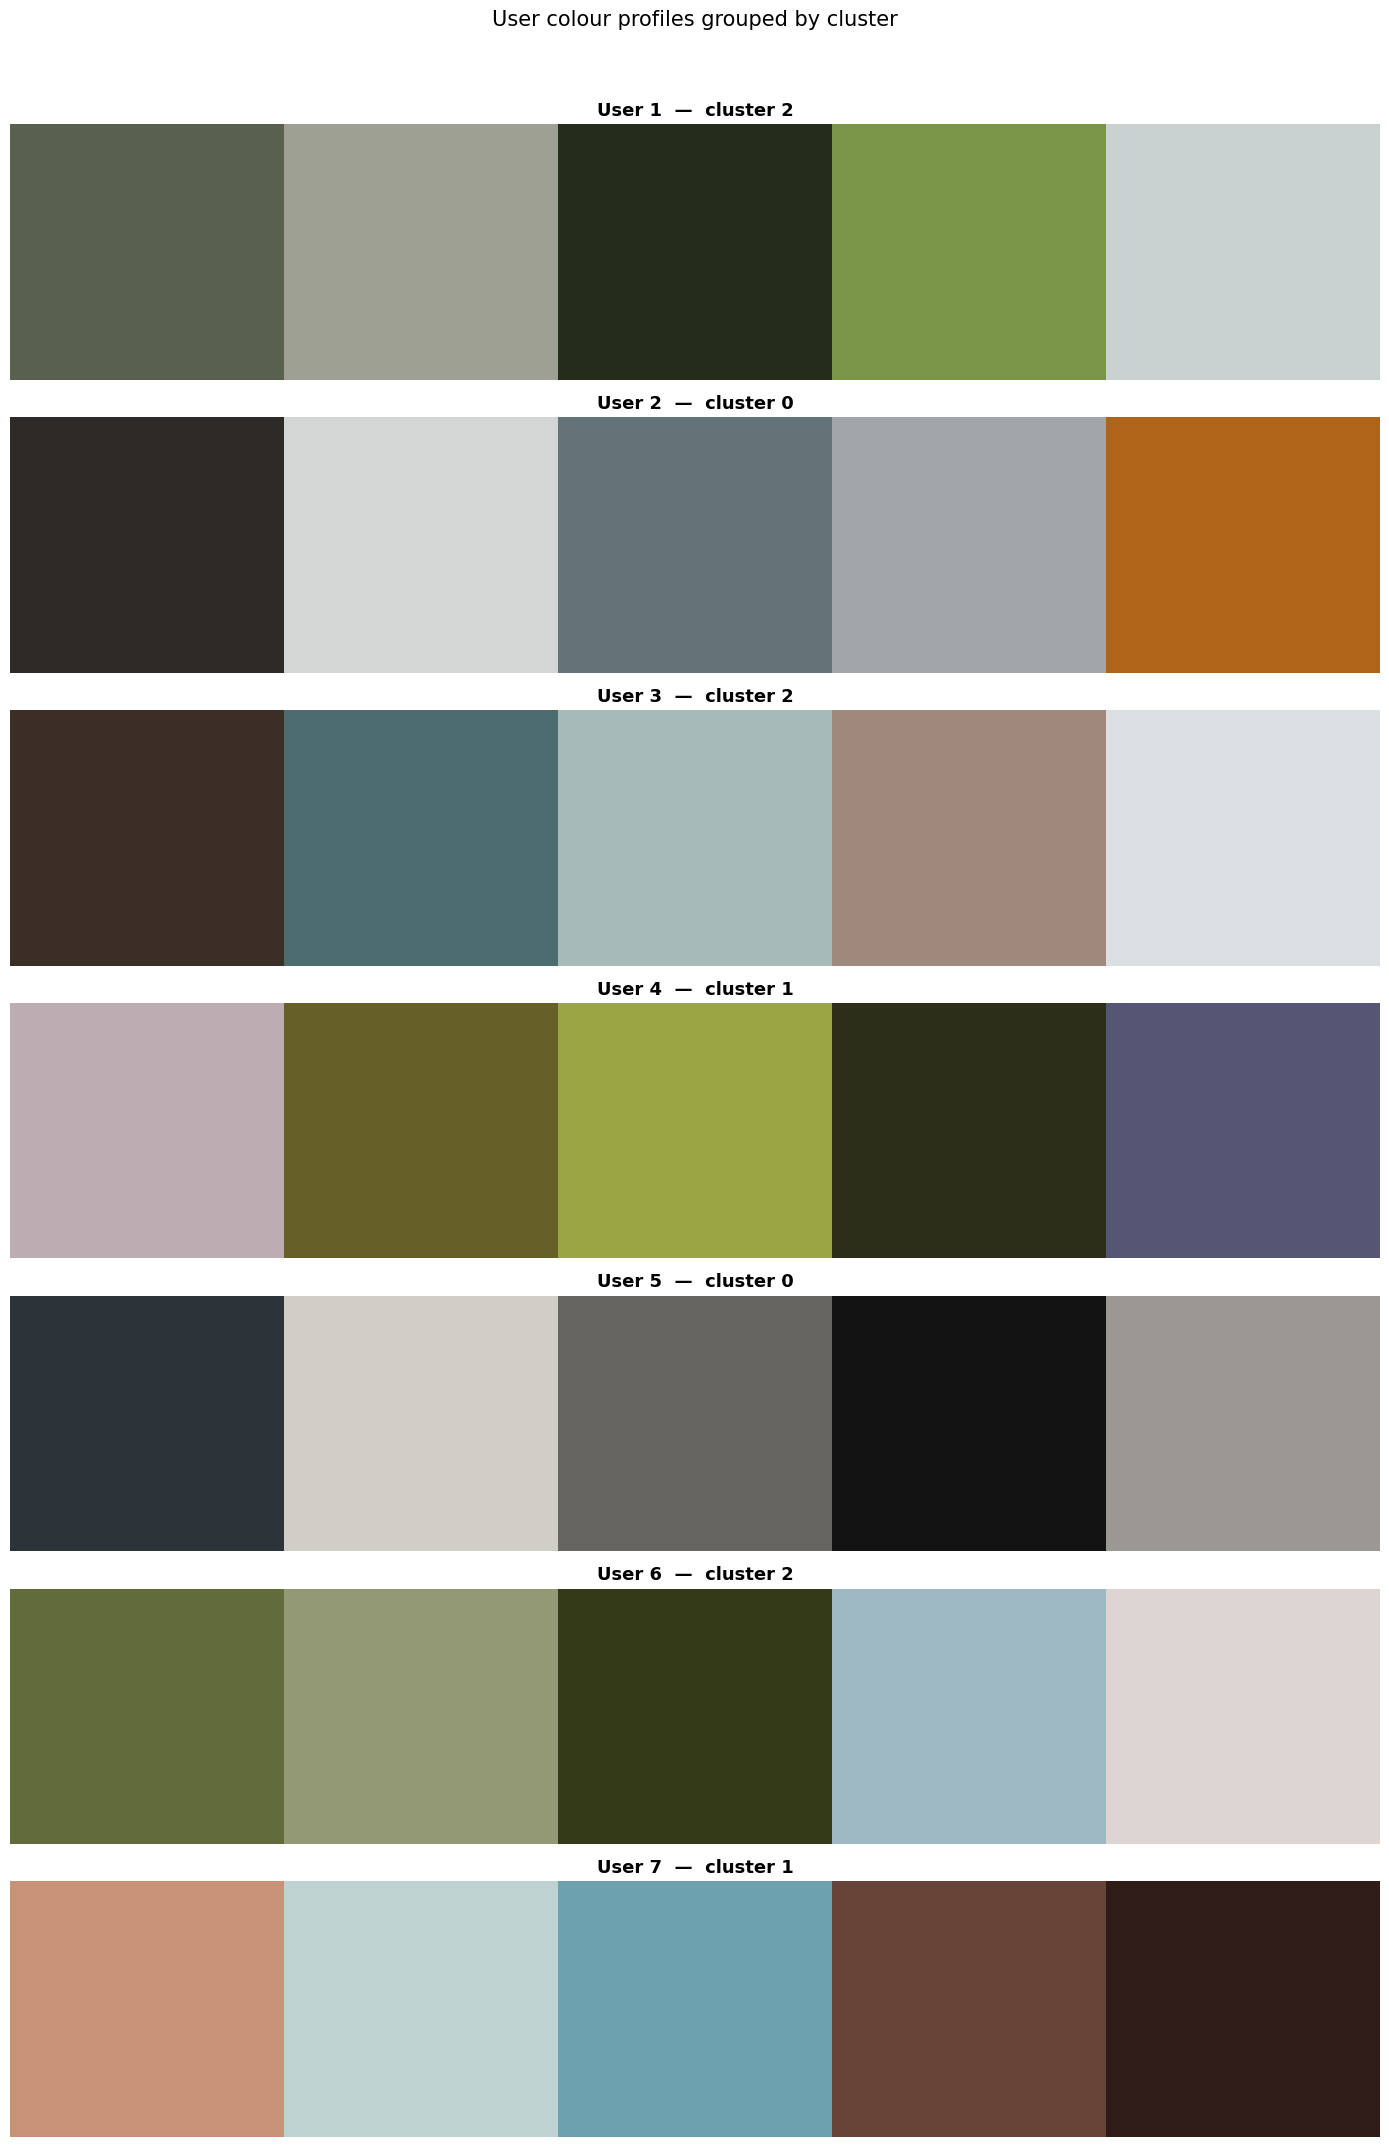

In [14]:
# Visualisation 1 — colour palette swatch per user, titled by cluster
SWATCH_W, SWATCH_H = 80, 60

fig, axes = plt.subplots(len(user_ids), 1, figsize=(14, 3 * len(user_ids)))
if len(user_ids) == 1:
    axes = [axes]

for i, (uid, profile, lbl) in enumerate(zip(user_ids, user_profiles, cluster_labels)):
    colors_rgb = profile.reshape(-1, 3)
    n = len(colors_rgb)
    palette_img = np.zeros((SWATCH_H, n * SWATCH_W, 3), dtype=np.uint8)
    for j, rgb in enumerate(colors_rgb):
        palette_img[:, j * SWATCH_W:(j + 1) * SWATCH_W] = np.clip(rgb, 0, 255).astype(np.uint8)

    axes[i].imshow(palette_img, aspect="auto")
    axes[i].set_title(
        f"User {uid}  —  cluster {lbl}",
        fontsize=13,
        fontweight="bold",
    )
    axes[i].axis("off")

plt.suptitle("User colour profiles grouped by cluster", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

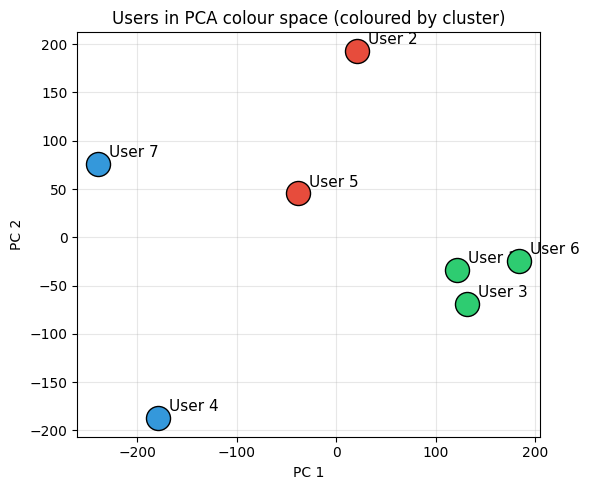

In [63]:
# Visualisation 2 — 2-D PCA scatter of user colour profiles
if len(user_profiles) >= 2:
    n_components = min(2, len(user_profiles) - 1, user_profiles.shape[1])
    pca = PCA(n_components=n_components)
    coords = pca.fit_transform(user_profiles)

    fig, ax = plt.subplots(figsize=(6, 5))
    for i, (uid, lbl) in enumerate(zip(user_ids, cluster_labels)):
        x = coords[i, 0]
        y = coords[i, 1] if coords.shape[1] > 1 else 0
        ax.scatter(x, y, s=300,
                   color=cluster_colors[lbl % len(cluster_colors)],
                   edgecolors="black", zorder=3)
        ax.annotate(f"User {uid}", (x, y),
                    textcoords="offset points", xytext=(8, 5), fontsize=11)

    ax.set_title("Users in PCA colour space (coloured by cluster)")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
def get_favorite_size(user_id):
    user = next((u for u in user_table if u["id"] == user_id), None)
    if not user:
        return None

    size_categories = []
    for filename in user["favorite"]:
        label_info = labels_dict.get(filename)
        if label_info:
            size_categories.append(label_info["size_category"])

    if not size_categories:
        return None

    # Retourne la catégorie de taille la plus fréquente
    return max(set(size_categories), key=size_categories.count)

In [17]:
def get_favorite_tags(user_id, top_n=5):
    user = next((u for u in user_table if u["id"] == user_id), None)
    if not user:
        return None

    tags = []
    for filename in user["favorite"]:
        label_info = labels_dict.get(filename)
        if label_info:
            tags.extend(label_info["tags"])

    if not tags:
        return None

    # Retourne les tags les plus fréquents
    tag_counts = {}
    for tag in tags:
        tag_counts[tag] = tag_counts.get(tag, 0) + 1

    sorted_tags = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)
    return [tag for tag, count in sorted_tags][:top_n]

In [18]:
def get_prefered_images(user_id):
    user = next((u for u in user_table if u["id"] == user_id), None)
    if not user:
        return None

    return user["favorite"]

In [19]:
import webcolors

def closest_color_name(rgb):
    min_dist = float('inf')
    closest = None
    
    # webcolors >= 24.x
    names = webcolors.names("css3")
    for name in names:
        r, g, b = webcolors.hex_to_rgb(webcolors.name_to_hex(name))
        dist = (r - rgb[0])**2 + (g - rgb[1])**2 + (b - rgb[2])**2
        if dist < min_dist:
            min_dist = dist
            closest = name
    return closest

In [20]:
def get_user_prefered_color_label(user_id, top_n=5):
    user = next((u for u in user_table if u["id"] == user_id), None)
    if not user:
        return None

    #rgb values
    user_prefered_color = get_user_color_profile(user, images_labels)
    if user_prefered_color is None:
        return None
    
    color_names = []
    for i in range(0, len(user_prefered_color), 3):
        rgb = user_prefered_color[i:i+3]
        color_name = closest_color_name(rgb)
        color_names.append(color_name)

    if not color_names:
        return None

    # Count occurrences of each color
    color_counts = {}
    for color in color_names:
        color_counts[color] = color_counts.get(color, 0) + 1

    # Sort colors by count and return the top n
    sorted_colors = sorted(color_counts.items(), key=lambda x: x[1], reverse=True)
    return [color for color, count in sorted_colors[:top_n]]

In [27]:
def generate_user_preferences(user_id):
    return {
        "user_id": user_id,
        "favorite_colors": get_user_prefered_color_label(user_id, top_n=3),
        "orientation": get_favorite_orientation(user_id),
        "size_category": get_favorite_size(user_id),
        "tags": get_favorite_tags(user_id, top_n=3),
        "prefered_images": get_prefered_images(user_id),
    }

In [29]:
#export preferences to json for all users
user_preferences = []
for user in user_table:
    prefs = generate_user_preferences(user["id"])
    user_preferences.append(prefs)
output_path = DATA_DIR / "users.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(user_preferences, f, ensure_ascii=False, indent=2)

## Tâche 5 - Système de recommandation

Nous allons utiliser le filtrage basé sur le contenu (utilisant la classification).

In [33]:
IMAGES_DIR = Path("images")
DATA_DIR = Path("data")

IMAGES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

In [34]:
from sklearn import tree
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [35]:
with open(DATA_DIR / "images_labels.json", "r", encoding="utf-8") as f:
    images_labels = json.load(f)

with open(DATA_DIR / "users.json", "r", encoding="utf-8") as f:
    users_data = json.load(f)

with open(DATA_DIR / "images_metadata.json", "r", encoding="utf-8") as f:
    images_metadata = json.load(f)


In [ ]:
# this fonction build a data table for training a model, using the user preferences and the image labels
def build_user_preference_data_table(user_id):
    data_rows = []
    for user in users_data:
        if user["user_id"] == user_id:
            favorite_images = user["prefered_images"]

        for img_name in favorite_images:
            if img_name in images_labels:
                label_info = images_labels[img_name]
                metadata_info = next((item for item in images_metadata if item["nom_fichier"] == img_name), None)

                row = {
                    "user_id": user_id,
                    "orientation": label_info["orientation"],
                    "size_category": label_info["size_category"],
                    "tags": ", ".join(label_info["tags"]),
                    "color_names": ", ".join(label_info["color_names"]),
                    "category": metadata_info["categorie"] if metadata_info else None
                }
                data_rows.append(row)

    df = pd.DataFrame(data_rows)
    return df

In [2]:
# this function trains a model for a specific user, used after to see if  user could like the image
def train_model_for_user(df):
    # Encode categorical features
    le_orientation = LabelEncoder()
    le_size = LabelEncoder()
    le_tags = LabelEncoder()
    le_colors = LabelEncoder()

    df["orientation_encoded"] = le_orientation.fit_transform(df["orientation"])
    df["size_encoded"] = le_size.fit_transform(df["size_category"])
    df["tags_encoded"] = le_tags.fit_transform(df["tags"])
    df["colors_encoded"] = le_colors.fit_transform(df["color_names"])

    # Target variable (for simplicity, we use category as target, but it could be a binary like/dislike)
    le_category = LabelEncoder()
    df["category_encoded"] = le_category.fit_transform(df["category"])

    features = ["orientation_encoded", "size_encoded", "tags_encoded", "colors_encoded"]
    X = df[features]
    y = df["category_encoded"]

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    return model, le_category    

## Prédiction like/dislike par utilisateur

On entraîne un modèle de classification binaire pour chaque utilisateur :
- `liked = 1` pour ses images favorites
- `liked = 0` pour des images non favorites (échantillonnées)

Le modèle apprend à partir des caractéristiques d'image (orientation, taille, catégorie, recouvrement tags/couleurs avec le profil utilisateur).

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


metadata_by_name = {item["nom_fichier"]: item for item in images_metadata}
users_by_id = {u["user_id"]: u for u in users_data}


def build_user_profile(user_id):
    user = users_by_id.get(user_id)
    if user is None:
        raise ValueError(f"Utilisateur inconnu: {user_id}")

    favorites = [img for img in user["prefered_images"] if img in images_labels]
    if not favorites:
        raise ValueError(f"Aucune image favorite exploitable pour user {user_id}")

    tags_counter = Counter()
    colors_counter = Counter()
    orient_counter = Counter()
    size_counter = Counter()
    cat_counter = Counter()

    for img_name in favorites:
        lbl = images_labels[img_name]
        meta = metadata_by_name.get(img_name, {})

        orient_counter.update([lbl.get("orientation")])
        size_counter.update([lbl.get("size_category")])
        cat_counter.update([meta.get("categorie")])
        tags_counter.update(lbl.get("tags", []))
        colors_counter.update(lbl.get("color_names", []))

    return {
        "user_id": user_id,
        "favorites": set(favorites),
        "top_tags": {t for t, _ in tags_counter.most_common(20)},
        "top_colors": {c for c, _ in colors_counter.most_common(10)},
        "favorite_orientation": orient_counter.most_common(1)[0][0],
        "favorite_size": size_counter.most_common(1)[0][0],
        "favorite_category": cat_counter.most_common(1)[0][0],
    }


def image_to_feature_row(img_name, profile):
    lbl = images_labels.get(img_name)
    if lbl is None:
        return None

    meta = metadata_by_name.get(img_name, {})
    img_tags = set(lbl.get("tags", []))
    img_colors = set(lbl.get("color_names", []))

    return {
        "image_name": img_name,
        "orientation": lbl.get("orientation", "unknown"),
        "size_category": lbl.get("size_category", "unknown"),
        "category": meta.get("categorie", "unknown"),
        "tags_overlap": len(img_tags & profile["top_tags"]),
        "colors_overlap": len(img_colors & profile["top_colors"]),
    }

In [ ]:
def build_user_binary_dataset(user_id, negative_ratio=1.0, random_state=42):
    profile = build_user_profile(user_id)

    all_imgs = [img for img in images_labels.keys() if image_to_feature_row(img, profile) is not None]
    positive_imgs = [img for img in all_imgs if img in profile["favorites"]]
    negative_pool = [img for img in all_imgs if img not in profile["favorites"]]

    if not positive_imgs:
        raise ValueError(f"Pas d'images positives pour user {user_id}")
    if not negative_pool:
        raise ValueError("Pas d'images negatives disponibles")

    n_neg = max(1, int(len(positive_imgs) * negative_ratio))
    rng = np.random.default_rng(random_state)
    chosen_negatives = list(rng.choice(negative_pool, size=min(n_neg, len(negative_pool)), replace=False))

    rows = []
    for img_name in positive_imgs:
        row = image_to_feature_row(img_name, profile)
        row["liked"] = 1
        rows.append(row)

    for img_name in chosen_negatives:
        row = image_to_feature_row(img_name, profile)
        row["liked"] = 0
        rows.append(row)

    df = pd.DataFrame(rows)
    return df, profile


def train_user_like_model(user_id, negative_ratio=1.0, random_state=42):
    df, profile = build_user_binary_dataset(
        user_id=user_id,
        negative_ratio=negative_ratio,
        random_state=random_state,
    )

    feature_cols = ["orientation", "size_category", "category", "tags_overlap", "colors_overlap"]
    X = df[feature_cols]
    y = df["liked"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["orientation", "size_category", "category"]),
            ("num", "passthrough", ["tags_overlap", "colors_overlap"]),
        ]
    )

    model = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state)),
        ]
    )

    model.fit(X, y)

    y_pred = model.predict(X)
    print(f"Train accuracy (user {user_id}): {accuracy_score(y, y_pred):.3f}")
    print(classification_report(y, y_pred, digits=3))

    return {
        "user_id": user_id,
        "profile": profile,
        "model": model,
        "train_df": df,
        "feature_cols": feature_cols,
    }

In [ ]:
def predict_user_like_proba(bundle, image_name):
    row = image_to_feature_row(image_name, bundle["profile"])
    if row is None:
        return None

    X_one = pd.DataFrame([{k: row[k] for k in bundle["feature_cols"]}])
    proba_like = float(bundle["model"].predict_proba(X_one)[0, 1])

    return {
        "user_id": bundle["user_id"],
        "image_name": image_name,
        "like_probability": round(proba_like, 4),
    }


def recommend_images_for_user(bundle, top_k=5, only_unseen=True):
    candidates = list(images_labels.keys())
    if only_unseen:
        candidates = [img for img in candidates if img not in bundle["profile"]["favorites"]]

    scored = []
    for img_name in candidates:
        pred = predict_user_like_proba(bundle, img_name)
        if pred is not None:
            scored.append(pred)

    scored.sort(key=lambda x: x["like_probability"], reverse=True)
    return scored[:top_k]

In [ ]:
# Exemple d'utilisation
user_id = 1
bundle_u1 = train_user_like_model(user_id, negative_ratio=1.5, random_state=42)

# Score d'une image précise
example_image = next(iter(images_labels.keys()))
print("Prediction image unique:")
print(predict_user_like_proba(bundle_u1, example_image))

# Top recommandations non vues
print("\nTop recommandations:")
for rec in recommend_images_for_user(bundle_u1, top_k=8, only_unseen=True):
    print(rec)